<a href="https://colab.research.google.com/github/Macmil25/Timeseries/blob/main/Harare_wetland.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project: Harare Wetland Analysis

 Project Introduction and Objective

This project focuses on an Environmental Data Analysis and Predictive Modeling of the Harare_Combined_Wetlands_Dataset.csv.

The primary objective is to understand and predict the sensitivity levels of wetlands in Harare using available geographical and environmental features. This involves several key stages:

1.Exploratory Data Analysis (EDA): To thoroughly understand the dataset's structure, distributions, relationships between variables, and to identify and handle missing values.

2.Wetland Clustering using K-Means: To identify natural groupings or segments of wetlands based on their characteristics.

3.Decision Tree Classification: To build a predictive model that can classify wetlands into different sensitivity levels (Highly Sensitive, Moderately Sensitive, Non-Sensitive).

The insights gained from this analysis are intended to provide actionable information for environmental planning, conservation efforts, policy-making, risk assessment, and resource allocation for the protection of Harare's wetlands.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

 Exploratory Data Analysis (EDA)

### Data Loading and Initial Overview

In [ ]:
# Load the dataset
df = pd.read_csv('/content/Harare_Combined_Wetlands_Dataset.csv')

print("First 5 rows of the dataset:")
display(df.head())

print("\nDataFrame Information (Data Types and Non-Null Counts):")
df.info()

First 5 rows of the dataset:


,Suburb_Name,Assigned_Ward,Latitude_Zone,Longitude_Zone,Wetland_Type,Sensitivity_Level,Has_Major_River,Has_Dam,Has_Health_Facility,Road_Density_Rating
0,Adylinn,Ward 8,"17°40'0""S","31°5'0""E",NaN,Non-Sensitive,0,0,0,Medium
1,Airport,Ward 35,"17°40'0""S","31°10'0""E",NaN,Non-Sensitive,0,0,0,Medium
2,Alexandra Park,Ward 39,"17°40'0""S","31°0'0""E",NaN,Non-Sensitive,0,0,0,Low
3,Arcadia,Ward 29,"17°50'0""S","30°55'0""E",Head Water,Highly Sensitive,1,0,0,Low
4,Ardbennie,Ward 14,"17°50'0""S","30°55'0""E",Head Water,Highly Sensitive,0,0,1,High



DataFrame Information (Data Types and Non-Null Counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Suburb_Name          117 non-null    object
 1   Assigned_Ward        117 non-null    object
 2   Latitude_Zone        117 non-null    object
 3   Longitude_Zone       117 non-null    object
 4   Wetland_Type         89 non-null     object
 5   Sensitivity_Level    117 non-null    object
 6   Has_Major_River      117 non-null    int64 
 7   Has_Dam              117 non-null    int64 
 8   Has_Health_Facility  117 non-null    int64 
 9   Road_Density_Rating  117 non-null    object
dtypes: int64(3), object(7)
memory usage: 9.3+ KB


### Missing Values Analysis

Columns with Missing Values:


,Missing Count,Missing Percentage
Wetland_Type,28,23.931624


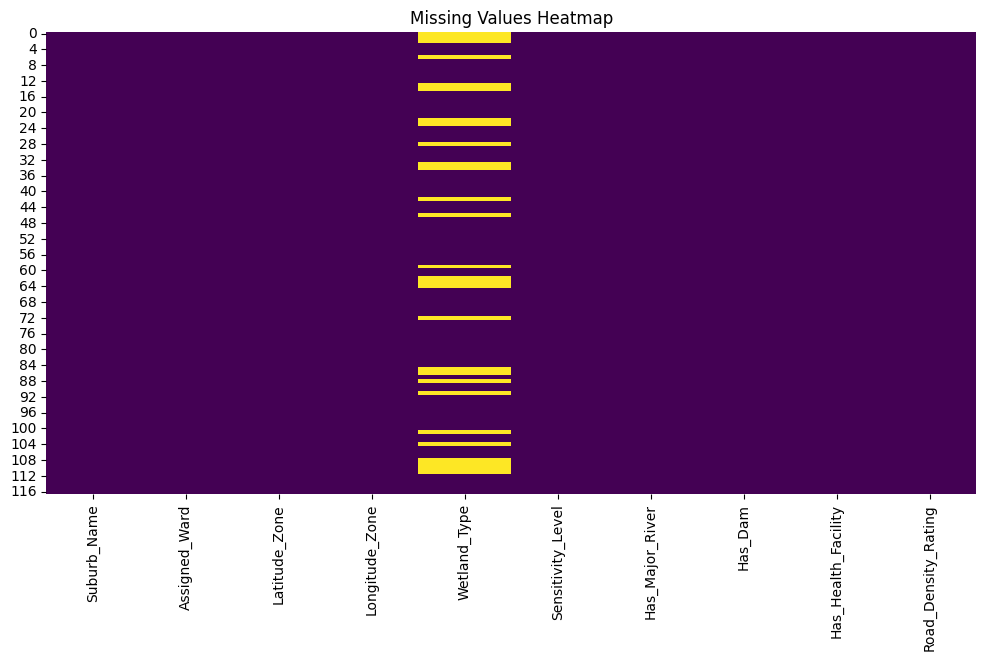

In [ ]:
# Calculate the percentage of missing values for each column
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

# Create a DataFrame to display missing values
missing_info = pd.DataFrame({"Missing Count": missing_values, "Missing Percentage": missing_percentage})

# Display only columns with missing values and sort
missing_info = missing_info[missing_info["Missing Count"] > 0].sort_values(by="Missing Percentage", ascending=False)

print("Columns with Missing Values:")
display(missing_info)

# Visualize missing values using a heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

### Handling Missing Values in 'Wetland_Type'

Given that 'Wetland_Type' has 23.93% missing values, these will be imputed with the mode (most frequent category) of the column to retain as much data as possible.

In [ ]:
# Impute missing 'Wetland_Type' values with the mode
mode_wetland_type = df['Wetland_Type'].mode()[0]
df['Wetland_Type'] = df['Wetland_Type'].fillna(mode_wetland_type)

print(f"Missing values in 'Wetland_Type' imputed with the mode: {mode_wetland_type}")

# Verify that there are no more missing values in 'Wetland_Type'
print("\nUpdated missing values information:")
display(df.isnull().sum().to_frame(name='Missing Count'))

Missing values in 'Wetland_Type' imputed with the mode: Head Water

Updated missing values information:


,Missing Count
Suburb_Name,0
Assigned_Ward,0
Latitude_Zone,0
Longitude_Zone,0
Wetland_Type,0
Sensitivity_Level,0
Has_Major_River,0
Has_Dam,0
Has_Health_Facility,0
Road_Density_Rating,0


### Basic Statistics for Numerical Columns

In [ ]:
print("Descriptive Statistics for Numerical Columns:")
display(df.describe())

Descriptive Statistics for Numerical Columns:


,Has_Major_River,Has_Dam,Has_Health_Facility
count,117.000000,117.000000,117.000000
mean,0.504274,0.213675,0.273504
std,0.502132,0.411663,0.447675
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000


### Categorical Columns Breakdown

Unique Values and Counts for Categorical Columns:

--- Column: Suburb_Name ---
Suburb_Name
Adylinn            1
Airport            1
Alexandra Park     1
Arcadia            1
Ardbennie          1
                  ..
Wichendon          1
Wild Geese         1
Willowvale         1
Wilmington Park    1
Workington         1
Name: count, Length: 117, dtype: int64
Skipping countplot for Suburb_Name due to high cardinality (117 unique values).

--- Column: Assigned_Ward ---
Assigned_Ward
Ward 35    6
Ward 18    6
Ward 8     5
Ward 36    5
Ward 25    5
Ward 11    5
Ward 14    4
Ward 29    4
Ward 39    4
Ward 13    4
Ward 20    4
Ward 10    4
Ward 28    4
Ward 5     4
Ward 43    3
Ward 31    3
Ward 37    3
Ward 1     3
Ward 27    3
Ward 42    3
Ward 7     3
Ward 45    3
Ward 33    3
Ward 3     2
Ward 24    2
Ward 17    2
Ward 23    2
Ward 16    2
Ward 40    2
Ward 22    2
Ward 21    2
Ward 15    1
Ward 32    1
Ward 44    1
Ward 38    1
Ward 46    1
Ward 12    1
Ward 26    1
Ward 41    1
Ward 34

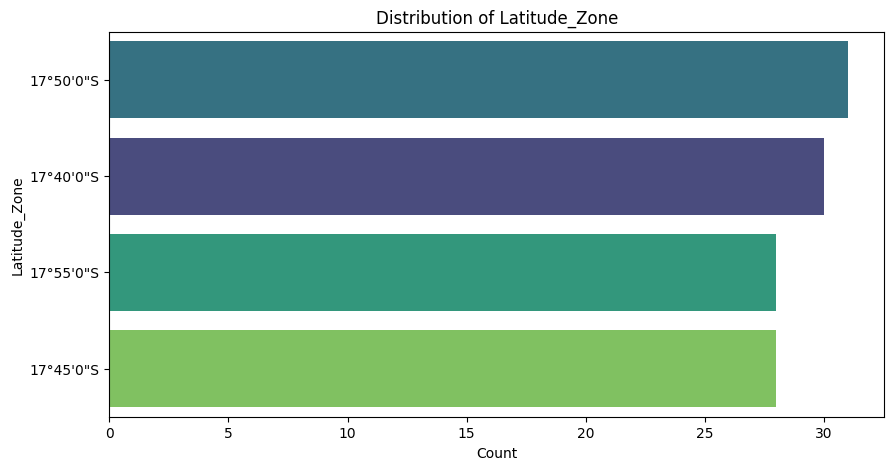


--- Column: Longitude_Zone ---
Longitude_Zone
31°10'0"E    34
30°55'0"E    29
31°0'0"E     28
31°5'0"E     26
Name: count, dtype: int64


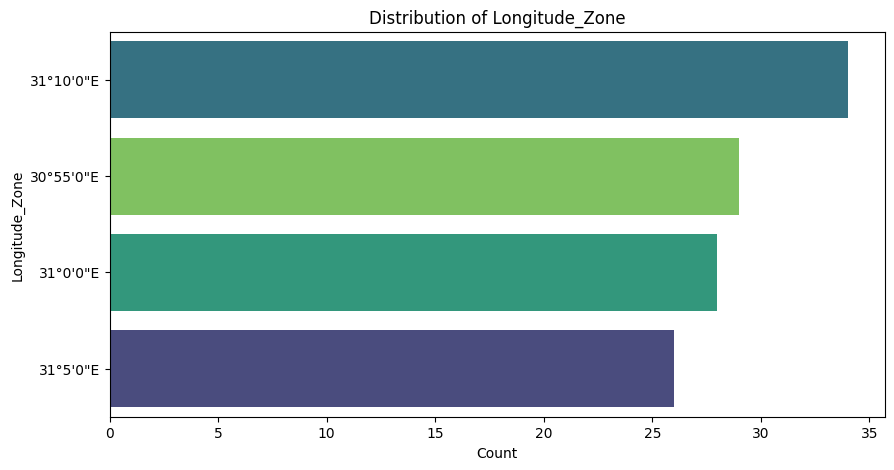


--- Column: Wetland_Type ---
Wetland_Type
Head Water      75
Middle Reach    42
Name: count, dtype: int64


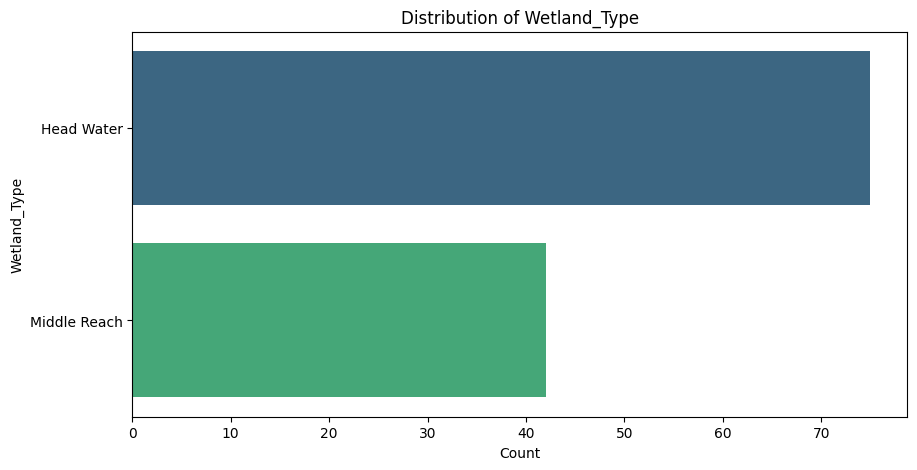


--- Column: Sensitivity_Level ---
Sensitivity_Level
Highly Sensitive        47
Moderately Sensitive    42
Non-Sensitive           28
Name: count, dtype: int64


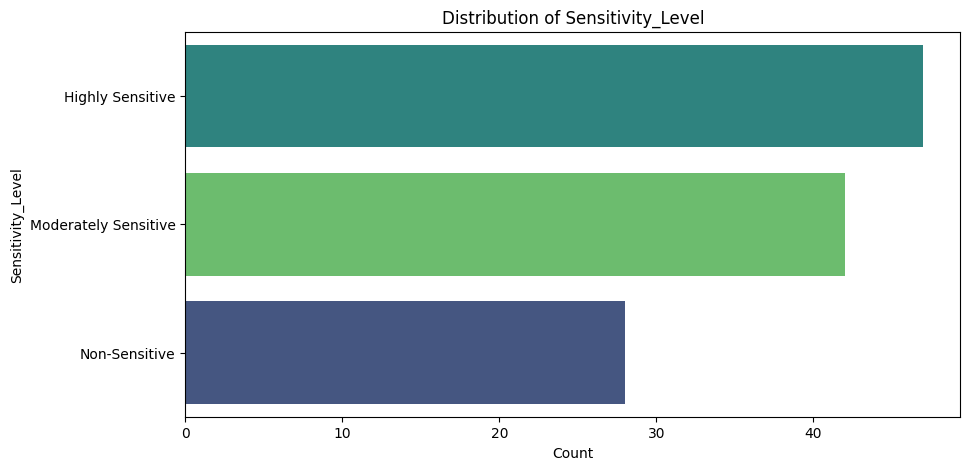


--- Column: Road_Density_Rating ---
Road_Density_Rating
High      48
Low       37
Medium    32
Name: count, dtype: int64


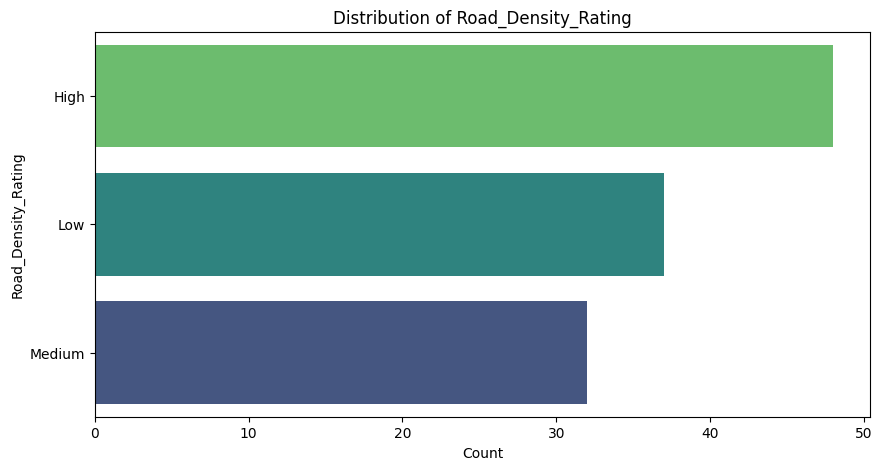

In [ ]:
# Get all object (categorical) columns
categorical_cols = df.select_dtypes(include='object').columns

print("Unique Values and Counts for Categorical Columns:")
for col in categorical_cols:
    print(f"\n--- Column: {col} ---")
    print(df[col].value_counts())

    # Plot distribution for categorical columns with fewer unique values
    if df[col].nunique() < 15: # Arbitrary threshold for plotting
        plt.figure(figsize=(10, 5))
        sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis', hue=df[col], legend=False)
        plt.title(f'Distribution of {col}')
        plt.xlabel('Count')
        plt.ylabel(col)
        plt.show()
    else:
        print(f"Skipping countplot for {col} due to high cardinality ({df[col].nunique()} unique values).")

### Univariate Analysis (Visualizations)

Distributions of Numerical Columns (Histograms):


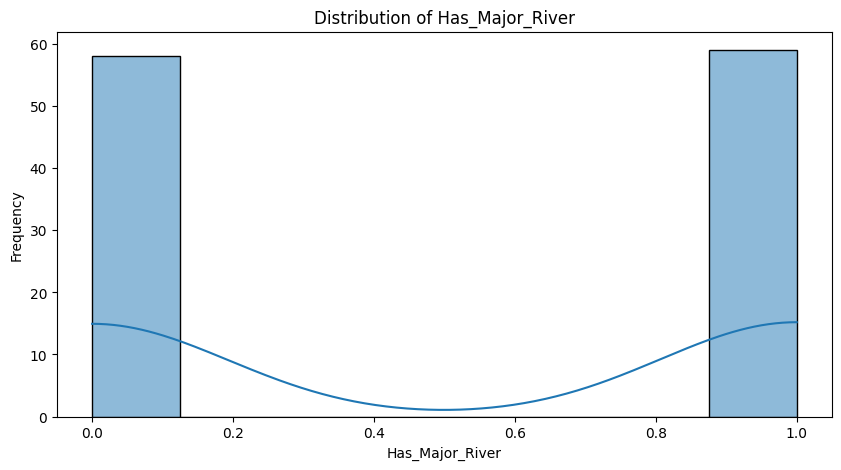

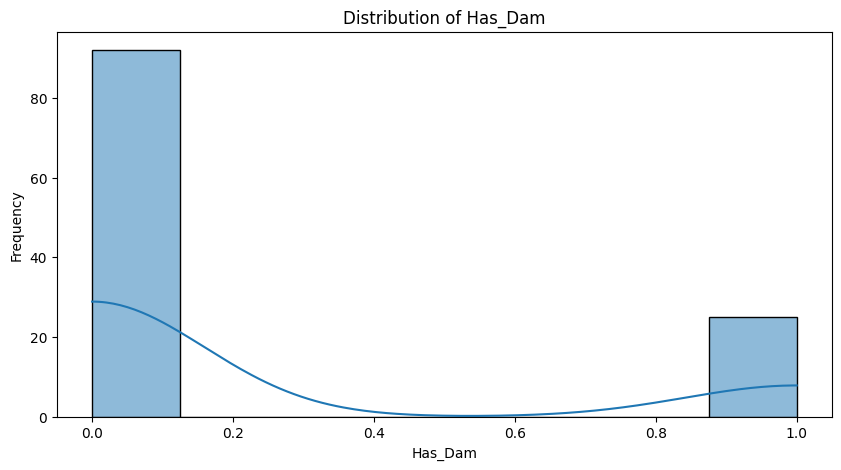

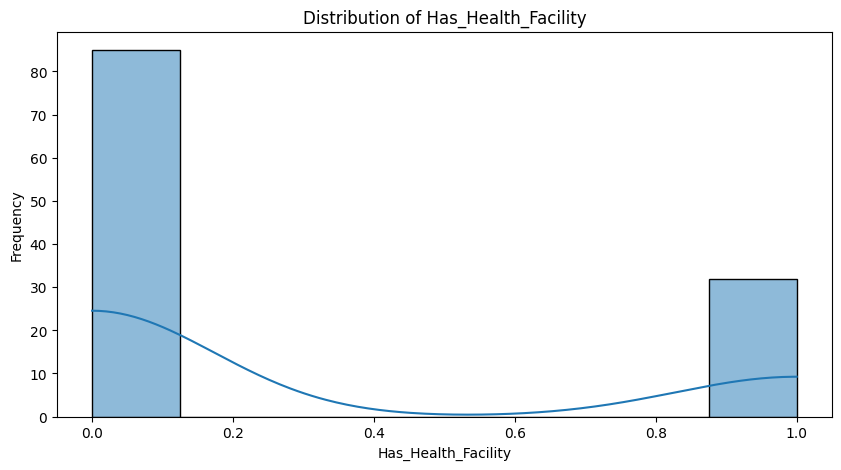

In [ ]:
# Get numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Distributions of Numerical Columns (Histograms):")
for col in numerical_cols:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

### Bivariate Analysis

This section explores relationships between pairs of variables.

#### Correlation between Numerical Features

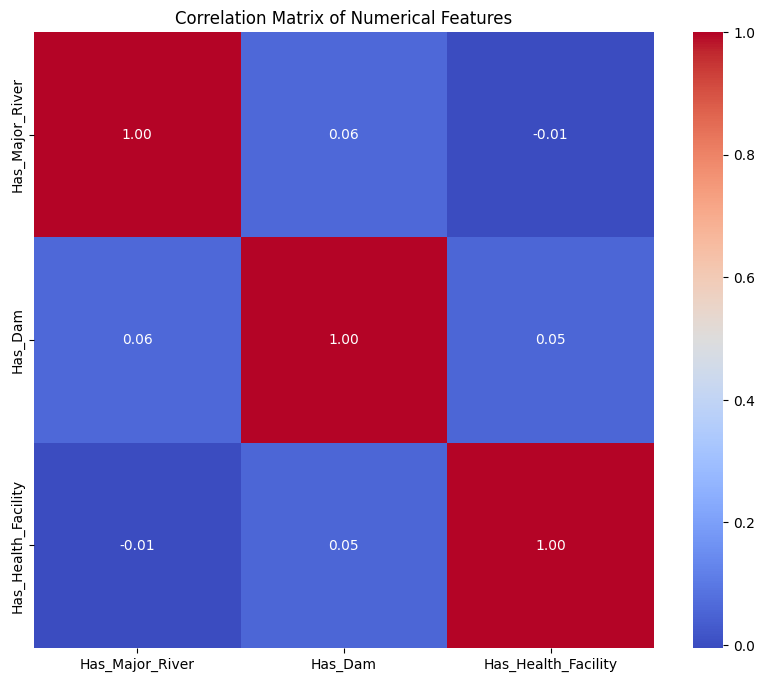

In [ ]:
# Calculate the correlation matrix for numerical columns
correlation_matrix = df[numerical_cols].corr()

# Plot the correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

#### Relationships between Categorical Features (e.g., Sensitivity Level and Water Sources)

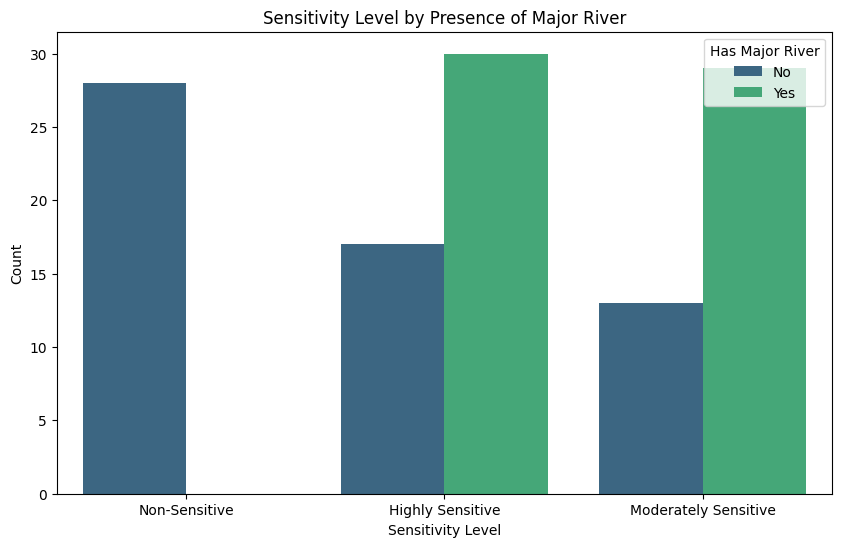

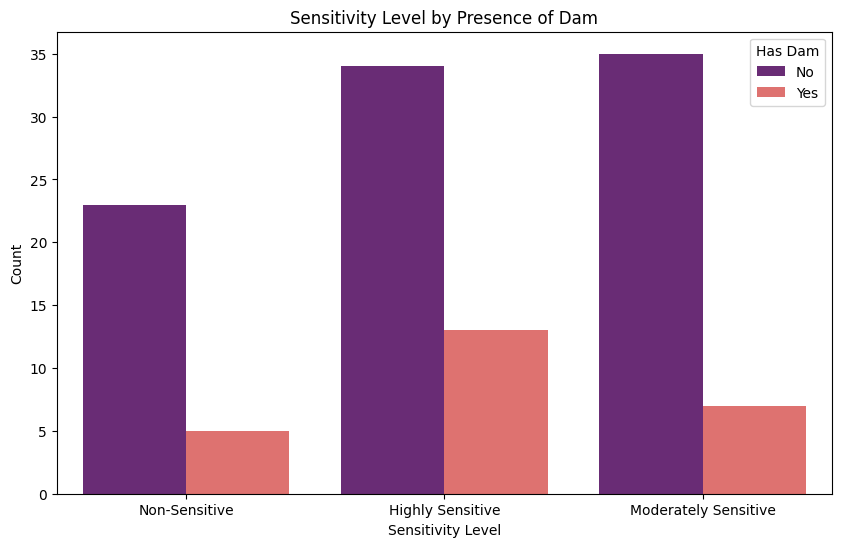

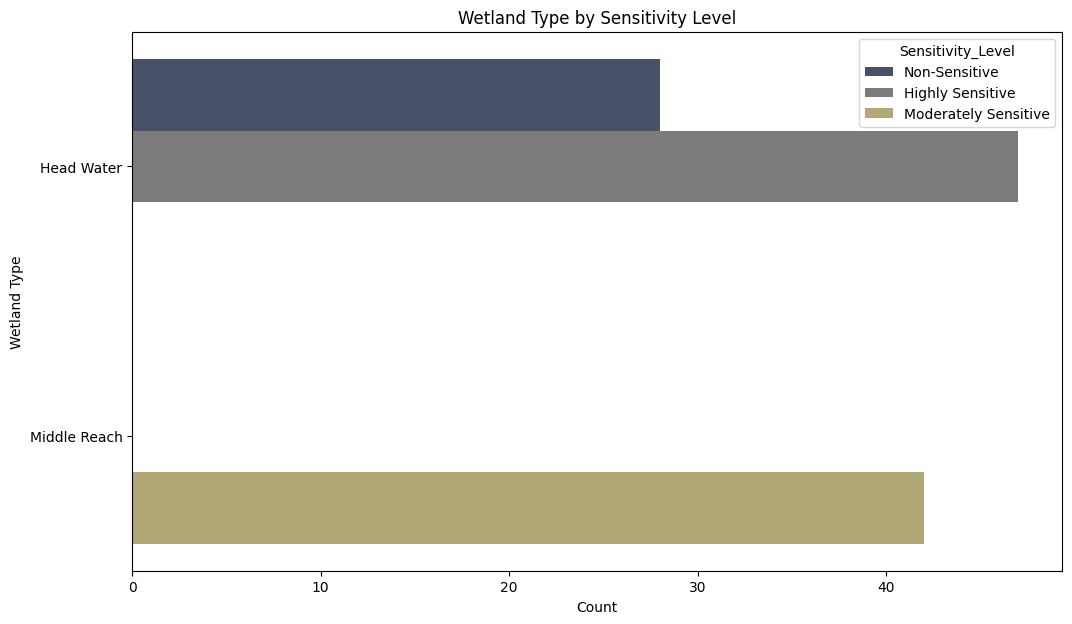

In [ ]:
# Relationship between Sensitivity_Level and Has_Major_River
plt.figure(figsize=(10, 6))
sns.countplot(x='Sensitivity_Level', hue='Has_Major_River', data=df, palette='viridis')
plt.title('Sensitivity Level by Presence of Major River')
plt.xlabel('Sensitivity Level')
plt.ylabel('Count')
plt.legend(title='Has Major River', labels=['No', 'Yes'])
plt.show()

# Relationship between Sensitivity_Level and Has_Dam
plt.figure(figsize=(10, 6))
sns.countplot(x='Sensitivity_Level', hue='Has_Dam', data=df, palette='magma')
plt.title('Sensitivity Level by Presence of Dam')
plt.xlabel('Sensitivity Level')
plt.ylabel('Count')
plt.legend(title='Has Dam', labels=['No', 'Yes'])
plt.show()

# Relationship between Wetland_Type and Sensitivity_Level
plt.figure(figsize=(12, 7))
sns.countplot(y='Wetland_Type', hue='Sensitivity_Level', data=df, palette='cividis')
plt.title('Wetland Type by Sensitivity Level')
plt.xlabel('Count')
plt.ylabel('Wetland Type')
plt.show()

### Grouping and Summary Table

In [ ]:
# Group by Sensitivity_Level and Wetland_Type, then summarize related numerical features
summary_table = df.groupby(['Sensitivity_Level', 'Wetland_Type']).agg(
    Has_Major_River_Count=('Has_Major_River', 'sum'),
    Has_Dam_Count=('Has_Dam', 'sum'),
    Has_Health_Facility_Count=('Has_Health_Facility', 'sum'),
    Number_of_Wetlands=('Suburb_Name', 'count') # Counting number of wetlands in each group
).reset_index()

print("Summary Table by Sensitivity Level and Wetland Type:")
display(summary_table.sort_values(by=['Sensitivity_Level', 'Number_of_Wetlands'], ascending=[True, False]))

Summary Table by Sensitivity Level and Wetland Type:


,Sensitivity_Level,Wetland_Type,Has_Major_River_Count,Has_Dam_Count,Has_Health_Facility_Count,Number_of_Wetlands
0,Highly Sensitive,Head Water,30,13,17,47
1,Moderately Sensitive,Middle Reach,29,7,11,42
2,Non-Sensitive,Head Water,0,5,4,28


### Wetland Sensitivity Levels by Suburb

To understand how wetland sensitivity varies geographically, visualize the distribution of Sensitivity_Level across different suburbs. Given the high number of unique suburbs,focusing on the top 10 suburbs with the most wetlands to ensure readability and highlight key areas.

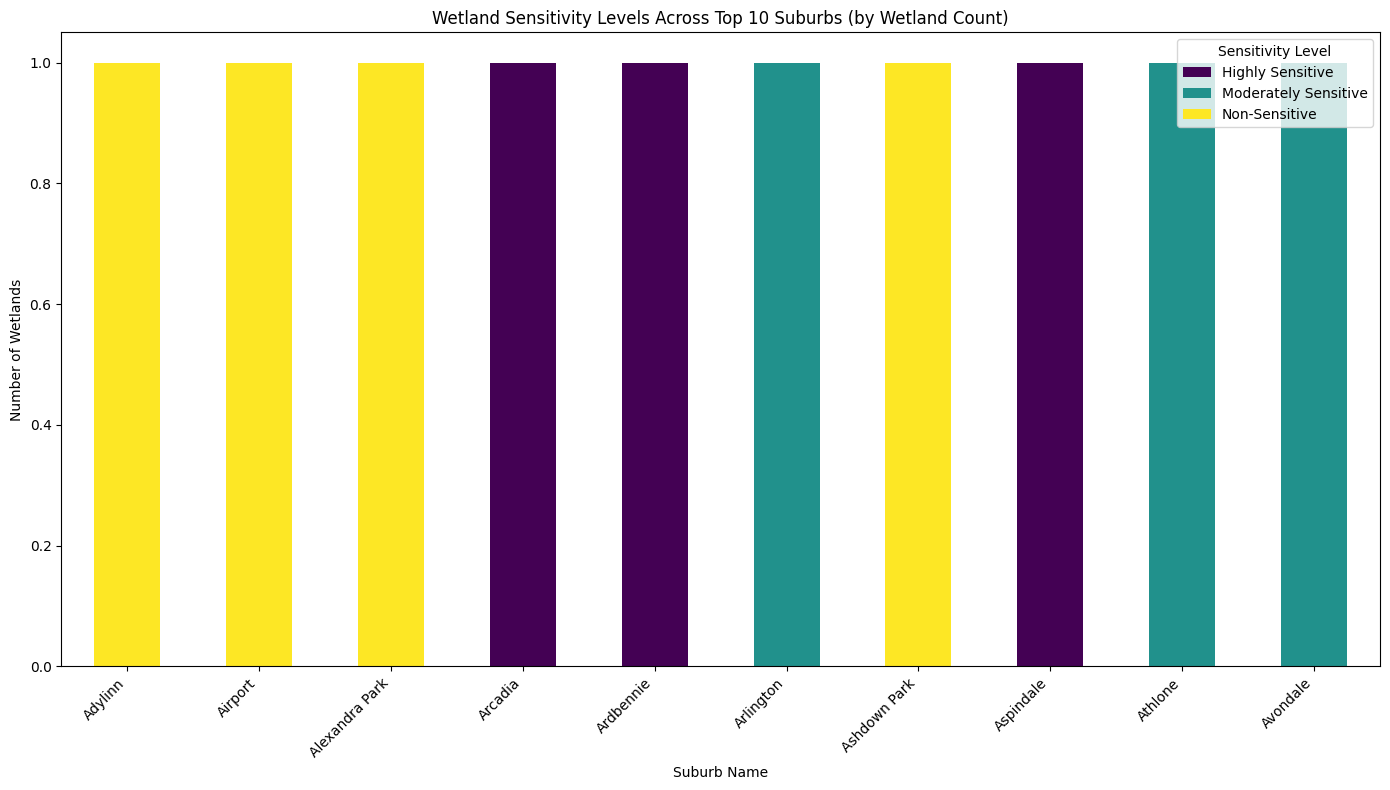

In [ ]:
# Calculate the number of wetlands per suburb
suburb_counts = df['Suburb_Name'].value_counts()

# Get the top 10 suburbs
top_10_suburbs = suburb_counts.head(10).index

# Filter the DataFrame to include only the top 10 suburbs
df_top_suburbs = df[df['Suburb_Name'].isin(top_10_suburbs)]

# Create a cross-tabulation of Suburb_Name and Sensitivity_Level
suburb_sensitivity_counts = pd.crosstab(df_top_suburbs['Suburb_Name'], df_top_suburbs['Sensitivity_Level'])

# Normalize to get proportions if desired, or just plot counts
# suburb_sensitivity_proportions = suburb_sensitivity_counts.div(suburb_sensitivity_counts.sum(axis=1), axis=0)

# Plotting the stacked bar chart
suburb_sensitivity_counts.plot(kind='bar', stacked=True, figsize=(14, 8), cmap='viridis')
plt.title('Wetland Sensitivity Levels Across Top 10 Suburbs (by Wetland Count)')
plt.xlabel('Suburb Name')
plt.ylabel('Number of Wetlands')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sensitivity Level')
plt.tight_layout()
plt.show()

## Wetland Clustering using K-Means

To identify natural groupings within the wetland dataset, the K-Means clustering algorithm is employed. This process involves several key steps: Feature Preparation, Feature Scaling, Optimal Cluster Determination, K-Means Application, and Cluster Analysis.

 1. Feature Preparation and Scaling

A subset of features relevant for differentiating wetlands, including Wetland_Type, Sensitivity_Level, Has_Major_River, Has_Dam, Has_Health_Facility, and Road_Density_Rating, will be selected. Categorical features will undergo one-hot encoding, and all features will be scaled to ensure equitable weighting during clustering.

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define features to use for clustering
features = ['Wetland_Type', 'Sensitivity_Level', 'Has_Major_River', 'Has_Dam', 'Has_Health_Facility', 'Road_Density_Rating']

# Separate categorical and numerical features for preprocessing
categorical_features = ['Wetland_Type', 'Sensitivity_Level', 'Road_Density_Rating']
numerical_features = ['Has_Major_River', 'Has_Dam', 'Has_Health_Facility'] # These are already numerical (0/1)

# Create a column transformer for one-hot encoding categorical features and scaling numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Create a pipeline for preprocessing the data
# We fit_transform the preprocessor to get the processed data
X_processed = preprocessor.fit_transform(df[features])

# Get the feature names after one-hot encoding
categorical_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numerical_features + list(categorical_feature_names)

print("Processed data shape:", X_processed.shape)
print("Features used for clustering:", all_feature_names)

Processed data shape: (117, 11)
Features used for clustering: ['Has_Major_River', 'Has_Dam', 'Has_Health_Facility', 'Wetland_Type_Head Water', 'Wetland_Type_Middle Reach', 'Sensitivity_Level_Highly Sensitive', 'Sensitivity_Level_Moderately Sensitive', 'Sensitivity_Level_Non-Sensitive', 'Road_Density_Rating_High', 'Road_Density_Rating_Low', 'Road_Density_Rating_Medium']


### 2. Determining the Optimal Number of Clusters (Elbow Method)

The Elbow Method aids in selecting the optimal number of clusters (k) by plotting the Within-Cluster Sum of Squares (WCSS) against the number of clusters. The 'elbow' point on the graph indicates an optimal balance between minimizing WCSS and maintaining a manageable number of clusters.

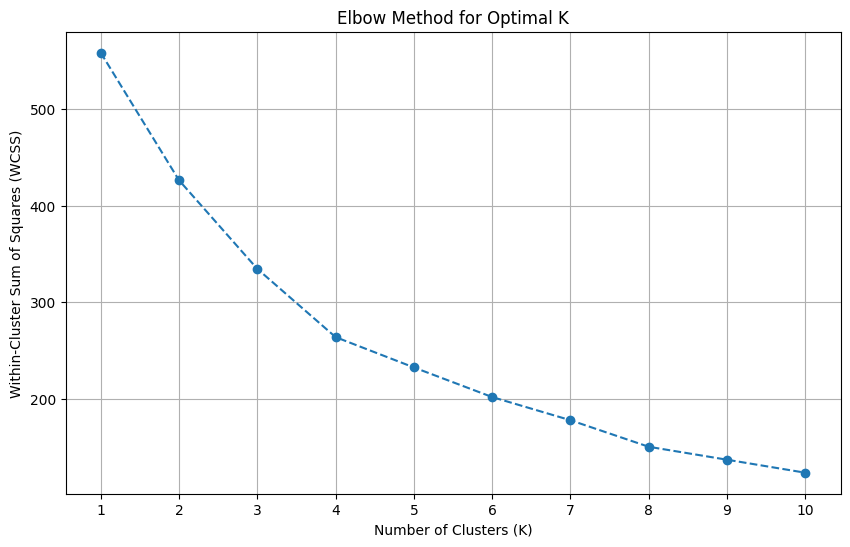

Based on the elbow plot, observe where the decrease in WCSS starts to slow down significantly to choose an optimal K.


In [ ]:
from sklearn.cluster import KMeans

# Calculate WCSS for different number of clusters
wcss = []
max_clusters = 10 # Let's try up to 10 clusters
for i in range(1, max_clusters + 1):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10) # n_init to suppress warning
    kmeans.fit(X_processed)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_clusters + 1), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(range(1, max_clusters + 1))
plt.grid(True)
plt.show()

print("Based on the elbow plot, observe where the decrease in WCSS starts to slow down significantly to choose an optimal K.")

Based on the Elbow Method plot, the 'elbow' point, where the rate of decrease in the Within-Cluster Sum of Squares (WCSS) significantly slows down, appears to be at k=3. Beyond this point, adding more clusters provides diminishing returns in terms of reducing WCSS, suggesting that 3 clusters offer a good balance between model complexity and explanatory power for the underlying data structure.

### 3. Applying K-Means Clustering

Subsequent to analyzing the elbow plot, an appropriate number of clusters will be selected, and the K-Means algorithm will be applied to assign each wetland to a cluster. For this analysis, `k=3` is assumed (this value can be adjusted based on the Elbow Method plot from the preceding cell).

In [ ]:
optimal_k = 3 # Adjust this value based on the Elbow Method plot

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_processed)

# Add the cluster labels to the original DataFrame
df['Cluster'] = cluster_labels

print(f"K-Means clustering applied with {optimal_k} clusters.")
print("First 5 rows with new 'Cluster' column:")
display(df.head())

K-Means clustering applied with 3 clusters.
First 5 rows with new 'Cluster' column:


,Suburb_Name,Assigned_Ward,Latitude_Zone,Longitude_Zone,Wetland_Type,Sensitivity_Level,Has_Major_River,Has_Dam,Has_Health_Facility,Road_Density_Rating,Cluster
0,Adylinn,Ward 8,"17°40'0""S","31°5'0""E",Head Water,Non-Sensitive,0,0,0,Medium,0
1,Airport,Ward 35,"17°40'0""S","31°10'0""E",Head Water,Non-Sensitive,0,0,0,Medium,0
2,Alexandra Park,Ward 39,"17°40'0""S","31°0'0""E",Head Water,Non-Sensitive,0,0,0,Low,0
3,Arcadia,Ward 29,"17°50'0""S","30°55'0""E",Head Water,Highly Sensitive,1,0,0,Low,1
4,Ardbennie,Ward 14,"17°50'0""S","30°55'0""E",Head Water,Highly Sensitive,0,0,1,High,0


### 4. Analyzing Cluster Characteristics

This section involves examining the characteristics of each cluster to discern their defining attributes. This includes analyzing the average values of numerical features and the distribution of categorical features within each cluster.

In [ ]:
# Analyze the distribution of features within each cluster
print("Cluster Profiles (Mean for numerical, distribution for categorical):")

for i in range(optimal_k):
    print(f"\n--- Cluster {i} ---")
    cluster_df = df[df['Cluster'] == i]

    print("\nNumerical Feature Means:")
    display(cluster_df[numerical_features].mean().to_frame(name='Mean Value'))

    print("\nCategorical Feature Distributions:")
    for col in categorical_features:
        print(f"  - {col}:")
        display(cluster_df[col].value_counts(normalize=True).to_frame(name='Proportion'))

Cluster Profiles (Mean for numerical, distribution for categorical):

--- Cluster 0 ---

Numerical Feature Means:


,Mean Value
Has_Major_River,0.000000
Has_Dam,0.000000
Has_Health_Facility,0.297872



Categorical Feature Distributions:
  - Wetland_Type:


,Proportion
Wetland_Type,
Head Water,0.744681
Middle Reach,0.255319


  - Sensitivity_Level:


...

,Proportion
Wetland_Type,
Head Water,0.72
Middle Reach,0.28


  - Sensitivity_Level:


,Proportion
Sensitivity_Level,
Highly Sensitive,0.52
Moderately Sensitive,0.28
Non-Sensitive,0.20


  - Road_Density_Rating:


,Proportion
Road_Density_Rating,
Low,0.40
High,0.36
Medium,0.24


### 5. Visualizing Clusters (using PCA for dimensionality reduction)

To facilitate a 2D visualization of the clusters, Principal Component Analysis (PCA) is employed to reduce the dimensionality of the processed data.

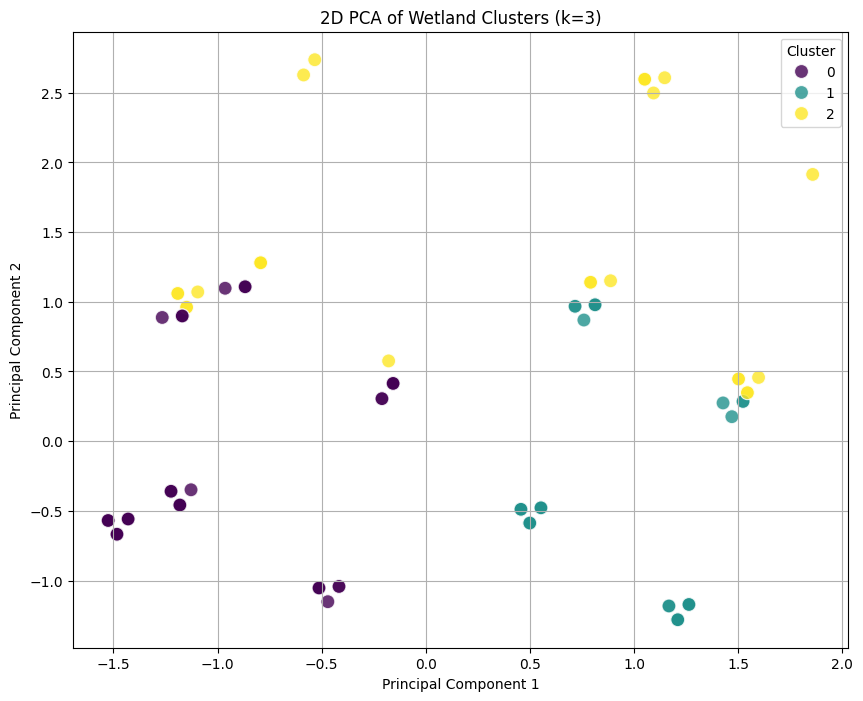

In [ ]:
from sklearn.decomposition import PCA

# Reduce dimensions for visualization using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

# Create a DataFrame for PCA results and cluster labels
pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['Cluster'] = cluster_labels

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Cluster',
    data=pca_df,
    palette='viridis',
    s=100, # size of points
    alpha=0.8
)
plt.title(f'2D PCA of Wetland Clusters (k={optimal_k})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.legend(title='Cluster')
plt.show()

## Decision Tree Classification

### 1. Data Preparation for Classification

Data preparation involves defining the features (X) and the target variable (y). The target variable will be Sensitivity_Level. Features will be a selected set, similar to those used in clustering, ensuring appropriate encoding and scaling. The Sensitivity_Level itself will be numerically encoded as the target.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define the target variable
y = df['Sensitivity_Level']

# Define features (excluding target and identifiers)
# We'll include Wetland_Type, Has_Major_River, Has_Dam, Has_Health_Facility, Road_Density_Rating
features_for_classification = ['Wetland_Type', 'Has_Major_River', 'Has_Dam', 'Has_Health_Facility', 'Road_Density_Rating']
X = df[features_for_classification]

# Identify categorical and numerical features for preprocessing
# 'Wetland_Type' and 'Road_Density_Rating' are categorical
categorical_features_clf = ['Wetland_Type', 'Road_Density_Rating']
numerical_features_clf = ['Has_Major_River', 'Has_Dam', 'Has_Health_Facility'] # Already numerical (0/1)

# Create a column transformer for preprocessing
preprocessor_clf = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_clf),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_clf)
    ])

# Encode the target variable (Sensitivity_Level) to numerical labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Original Sensitivity Levels:", y.unique())
print("Encoded Sensitivity Levels:", y_encoded)
print("Mapping:", list(label_encoder.classes_))

# Apply preprocessing to features
X_processed_clf = preprocessor_clf.fit_transform(X)

print("\nShape of preprocessed features (X_processed_clf):", X_processed_clf.shape)

Original Sensitivity Levels: ['Non-Sensitive' 'Highly Sensitive' 'Moderately Sensitive']
Encoded Sensitivity Levels: [2 2 2 0 0 1 2 0 1 1 0 1 0 2 2 0 0 1 1 0 1 0 2 2 0 0 0 1 2 0 0 0 1 2 2 0 0
 1 1 1 0 1 2 1 0 1 2 0 1 0 0 0 1 1 0 1 0 1 1 2 0 0 2 2 2 0 0 1 0 0 1 1 2 1
 1 0 1 0 1 0 1 0 1 0 1 2 2 1 2 0 0 2 0 1 1 0 1 0 0 1 0 2 1 0 2 1 1 1 2 2 2
 2 0 0 1 0 1]
Mapping: ['Highly Sensitive', 'Moderately Sensitive', 'Non-Sensitive']

Shape of preprocessed features (X_processed_clf): (117, 8)


### 2. Splitting Data into Training and Testing Sets

The processed data will be partitioned into training and testing sets to facilitate robust evaluation of the model's performance on unseen data. A typical allocation of 80% for training and 20% for testing will be utilized.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_processed_clf, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print("Target variable distribution in training set:", pd.Series(y_train).value_counts(normalize=True))
print("Target variable distribution in testing set:", pd.Series(y_test).value_counts(normalize=True))

Training set size: 93 samples
Testing set size: 24 samples
Target variable distribution in training set: 0    0.397849
1    0.365591
2    0.236559
Name: proportion, dtype: float64
Target variable distribution in testing set: 0    0.416667
1    0.333333
2    0.250000
Name: proportion, dtype: float64


### 3. Training a Decision Tree Classifier

Following data preparation, a Decision Tree Classifier will be initialized and trained using the prepared training data.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier
decision_tree_model = DecisionTreeClassifier(random_state=42)

# Train the model
decision_tree_model.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully.")

Decision Tree Classifier trained successfully.


### 4. Model Evaluation

The trained model's performance will be assessed against the test set. This evaluation will utilize standard classification metrics.

Accuracy: 0.7917

Classification Report:
                      precision    recall  f1-score   support

    Highly Sensitive       0.73      0.80      0.76        10
Moderately Sensitive       1.00      1.00      1.00         8
       Non-Sensitive       0.60      0.50      0.55         6

            accuracy                           0.79        24
           macro avg       0.78      0.77      0.77        24
        weighted avg       0.79      0.79      0.79        24



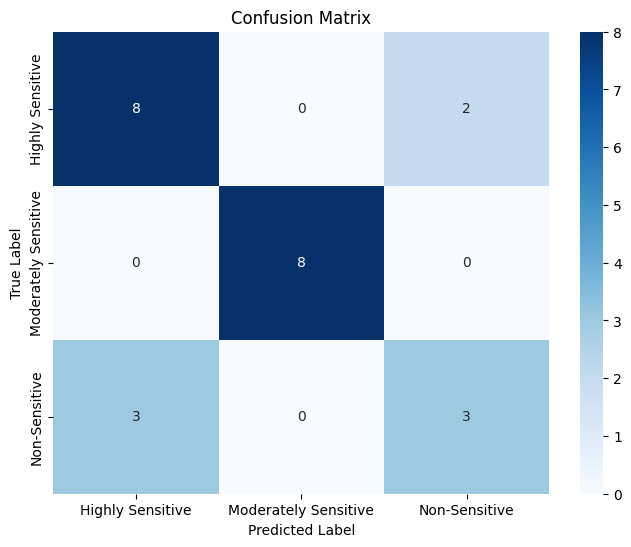

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Make predictions on the test set
y_pred = decision_tree_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

 Model Evaluation Summary

The Decision Tree Classifier achieved an overall accuracy of **79.17%** on the test set. The model performed perfectly in classifying all 8 'Moderately Sensitive' wetlands. For 'Highly Sensitive' wetlands, 8 out of 10 were correctly identified, with 2 misclassified as 'Non-Sensitive'. The model showed the most difficulty with 'Non-Sensitive' wetlands, correctly identifying only 3 out of 6, while incorrectly classifying the remaining 3 as 'Highly Sensitive'. This suggests a cautious bias, where the model tends to over-prioritize sensitivity, which, while reducing the risk of underestimating sensitivity, highlights an area for potential improvement in distinguishing truly non-sensitive cases.

Predicted:
            HS  MS  NS
Actual HS: [ 8,  0,  2]
Actual MS: [ 0,  8,  0]
Actual NS: [ 3,  0,  3]

(HS = Highly Sensitive, MS = Moderately Sensitive, NS = Non-Sensitive)

### 5. Feature Importance Visualization

To further understand the Decision Tree Classifier, the importance of each feature in making predictions is visualized. This helps in identifying which wetland characteristics are most influential in determining sensitivity levels.

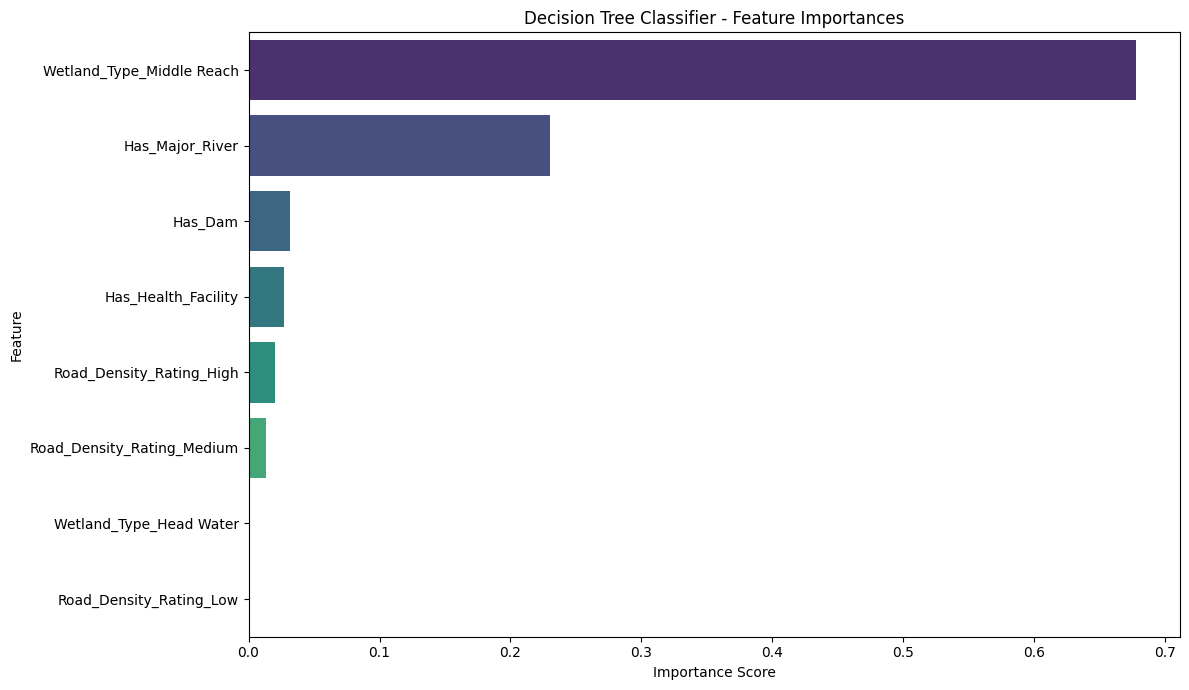

In [ ]:
importances = decision_tree_model.feature_importances_

# Get feature names after one-hot encoding
# We need to reconstruct the feature names in the order they were processed
one_hot_features = preprocessor_clf.named_transformers_['cat'].get_feature_names_out(categorical_features_clf)
feature_names_transformed = numerical_features_clf + list(one_hot_features)

feature_importances_df = pd.DataFrame({'Feature': feature_names_transformed, 'Importance': importances})
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importances_df, palette='viridis', hue='Feature', legend=False)
plt.title('Decision Tree Classifier - Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

 Summary: Harare Wetland Analysis

This project conducted an extensive analysis of the Harare_Combined_Wetlands_Dataset.

The Exploratory Data Analysis (EDA) phase revealed the dataset's structure, addressed missing values by imputing 'Wetland_Type' with the mode ('Head Water'), and identified key relationships between features such as Wetland_Type, Has_Major_River, and Has_Dam with Sensitivity_Level, including a geographical overview of sensitivity by suburb.

Subsequently, K-Means clustering was applied, which, following preprocessing and an Elbow Method suggesting three optimal clusters, revealed distinct natural groupings of wetlands within the dataset, visualized effectively through PCA.

Finally, a Decision Tree Classifier was implemented to predict wetland Sensitivity_Level. The model achieved an overall accuracy of 79.17% on the test set, demonstrating perfect classification for Moderately Sensitive wetlands, good performance for Highly Sensitive wetlands (80% recall), but struggling with Non-Sensitive wetlands (50% recall), often misclassifying them as Highly Sensitive, indicating a cautious bias.

Feature importance analysis highlighted Wetland_Type_Middle Reach and Has_Major_River as the most significant predictors of sensitivity.

This comprehensive analysis provides valuable insights into Harare's wetlands, their inherent groupings, and the factors influencing their sensitivity, offering a foundational tool for informed management and conservation strategies.

Recommendations and Future Work

Based on the analysis conducted, here are some recommendations and areas for future work:

### Recommendations:

1.  **Prioritize Highly Sensitive Wetlands**: Focus conservation efforts and protective measures on wetlands classified as Highly Sensitive, particularly those in areas identified with higher proportions of this sensitivity level. This aligns with the environmental pillar of ESG, emphasizing ecological preservation.

2.  **Investigate Non-Sensitive Wetland Misclassifications**: The model struggled most with Non-Sensitive wetlands. Further investigation into these misclassifications could involve collecting additional features or refining existing ones to better differentiate them from Highly Sensitive wetlands, thereby improving environmental risk assessment accuracy.

3.  **Utilize Feature Importance for Targeted Interventions**: The identified influential features such as 'Wetland_Type_Middle Reach' and 'Has_Major_River' should be key considerations in environmental impact assessments and development planning around wetlands. This enables targeted and efficient allocation of resources, reflecting responsible governance (ESG).

4.  **Explore Green Financing Mechanisms**: Given the ecological importance, investigate opportunities for green bonds, conservation grants, or other sustainable finance instruments to fund wetland protection and restoration projects. This aligns directly with sustainable development goals and attracts environmentally conscious investors.

### Future Work:

1.  **Incorporate More Granular Data**: Access to more detailed geographical data, land use patterns, population density, or specific ecological indicators could significantly improve model accuracy and provide deeper insights for comprehensive environmental management.

2.  **Explore Other Machine Learning Models**: Experiment with more advanced classification algorithms (e.g., Random Forest, Gradient Boosting, Neural Networks) to potentially improve predictive performance, especially for 'Non-Sensitive' wetlands, thereby enhancing the model's robustness.

3.  **Temporal Analysis**: If historical data becomes available, conducting a time-series analysis could reveal trends in wetland sensitivity changes over time, offering proactive management strategies and early warning systems for ecological degradation.

4.  **Spatial Analysis**: A more in-depth spatial analysis, possibly using GIS tools, could better visualize the relationships between wetland features and sensitivity, and identify interconnected wetland systems, crucial for regional planning.

5.  **Address User's Initial Query**: If data on 'ground shifting that cracks building foundations' becomes available, a separate analysis could be performed to investigate this specific concern and its relationship with wetland characteristics, providing a holistic view of urban environmental challenges.